# Proyecto Final

## Pipline del Notebook

1. EDA
* distribuciones (log)
* outliers
* correlaciones (Spearman)
2. Feature engineering
* ratios
* logs
* flags
3. Tests
* Mann-Whitney → corto vs largo
* Kruskal → género
* Spearman → relaciones
4. Modelo
* regresión (explicativo)
* clasificación (is_hit)

## Información del proyecto

### Datos descargados

**Desde diferentes pruebas de APi request trabajadas en distintas versiones del proyecto:**
- `backup_tracks.csv` — tracks enriquecidos via `track.getInfo` (nombre, artista, duración en ms, tag, playcount, listeners, published)
- `lastfm_dataset.csv` — tracks del pipeline multi-endpoint (aporta: country, genre_tag, rank_global, rank_by_country)
- `tags_dataset.csv` código añadido via método `track.getInfo` después de crear `backup_tracks.csv` 

### DataFrames:

| Nombre      | Significado               |
| ----------- | ------------------------- |
| df          | raw data                  |
| df_tracks   | datos de tracks |
| df_raw    | datos descargados             |
| df_clean    | datos limpios             |
| df_analysis | datos para análisis       |
| df_enriched | datos con features nuevas |

* Aclaracioens en de las variables:

| Variable    | Qué mide                         |
| ----------- | -------------------------------- |
| `playcount` | reproducciones de una canción    |
| `listeners` | oyentes de una canción           |
| `count`     | cuántas veces se usa un género   |
| `reach`     | cuántos usuarios usan ese género |


* tag_list[ ] = Lista de tracks por género (tag).
* tracks [ ] = Lista de tracks según tags encontrados.


### Endpoints

| Endpoint | Qué devuelve | Para qué lo usamos |
|---|---|---|
| `tag.getTopTags` | Tags globales con name, count, reach | Construir `df_tags` |
| `tag.getTopTracks` | Tracks por género | Construir `df_tracks` |
| `track.getInfo` | Metadata completa por mbid | Crea `backup_tracks.csv` |

---
## 1. Importaciones y configuración

In [1]:
import os
import ast
import time
import warnings
import pickle
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
# import statsmodels.api as sm

from scipy.stats import spearmanr, mannwhitneyu, kruskal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100


* os → trabajar con archivos/sistema(no lo estás usando aún ❗)
* time → pausas (útil para APIs → evitar rate limits)
* warnings → ocultar warnings molestos
* requests → hacer llamadas a la API
* numpy (np) → operaciones numéricas (NaN, arrays)
* pandas (pd) →  manipulación de datos
* matplotlib.pyplot → gráficos base
* mticker → formatear ejes
* seaborn → gráficos más bonitos

In [ ]:
import os

print("📍 Current working directory:")
print(os.getcwd())

print("\n📂 Archivos en este directorio:")
print(os.listdir())

print("\n📂 Archivos en data:")
print(os.listdir('data'))

print("\n📂 Archivos en data/processed:")
print(os.listdir('data/processed'))

---
## 2. Configuración API



### Función centralizada con validación de status_code y control de errores

In [ ]:
API_KEY = '63e059c3c912a3f642daf2372484d183'
BASE_URL = f'http://ws.audioscrobbler.com/2.0/?api_key={API_KEY}&'



def get_json(url):
    """Petición GET con validación de status y manejo de errores de red."""
    try:
        time.sleep(0.5)  # delay para no superar rate limit (~4 req/s, límite = 5)
        resp = requests.get(url, timeout=10)
        if resp.status_code != 200:
            print(f'  ⚠️  HTTP {resp.status_code} para: {url[:80]}')
            return None
        return resp.json()
    except requests.exceptions.RequestException as e:
        print(f'  ⚠️  Error de red: {e}')
        return None

print('✅ API configurada')

---
## 3. Extracción de datos y Construcción de `df_tracks`


### 1. Get top tags → `df_tags`

In [3]:
re = requests.get(f'{BASE_URL}method=tag.getTopTags&format=json')

if re.status_code == 200:
    print('Petición correcta')
    re_json = re.json()
else:
    raise Exception(f"Error en la petición: {re.status_code}")

Petición correcta


In [4]:
re_json['toptags']['tag'][:10]

[{'name': 'rock', 'count': 4069820, 'reach': 402953},
 {'name': 'electronic', 'count': 2499435, 'reach': 262252},
 {'name': 'seen live', 'count': 2194840, 'reach': 82563},
 {'name': 'alternative', 'count': 2131119, 'reach': 267229},
 {'name': 'pop', 'count': 2083017, 'reach': 233796},
 {'name': 'indie', 'count': 2065556, 'reach': 260482},
 {'name': 'female vocalists', 'count': 1634638, 'reach': 169167},
 {'name': 'metal', 'count': 1305873, 'reach': 159033},
 {'name': 'alternative rock', 'count': 1230585, 'reach': 170276},
 {'name': 'jazz', 'count': 1196725, 'reach': 149998}]

In [5]:
tag_list = []
for i in re_json['toptags']['tag']:
  tag_list.append(i['name'])
len(tag_list)

50

In [6]:
raw_tags = re_json.get('toptags', {}).get('tag', []) if re_json else []
df_tags = pd.DataFrame([{'name' : t.get('name', np.nan),
     'count': int(t.get('count', np.nan)),
     'reach': int(t.get('reach', np.nan))}
    for t in raw_tags])

print(f'df_tags: {df_tags.shape[0]} tags')
df_tags.head(10)

df_tags: 50 tags


,name,count,reach
0,rock,4069820,402953
1,electronic,2499435,262252
2,seen live,2194840,82563
3,alternative,2131119,267229
4,pop,2083017,233796
5,indie,2065556,260482
6,female vocalists,1634638,169167
7,metal,1305873,159033
8,alternative rock,1230585,170276
9,jazz,1196725,149998


In [7]:

df_tags = pd.read_csv('../data/raw/tags_dataset.csv')


In [8]:
df_tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    50 non-null     str  
 1   count   50 non-null     int64
 2   reach   50 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.3 KB


* Limpieza de la columna tag para poder importar correctamente count y reach data:

In [9]:
df_tags['count'].isnull().sum()

np.int64(0)

### 2. Get info → genera `backup_tracks.csv`

In [13]:
prueba = requests.get(f"{BASE_URL}method=track.getInfo&mbid={df_tracks['mbid'].iloc[0]}&format=json")
prueba_json = prueba.json()
prueba_json


{'track': {'name': 'The Chain',
  'mbid': '021c73b9-c6d5-41de-a852-8b990b7e24e7',
  'url': 'https://www.last.fm/music/Fleetwood+Mac/_/The+Chain',
  'duration': '269000',
  'streamable': {'#text': '0', 'fulltrack': '0'},
  'listeners': '624291',
  'playcount': '4516591',
  'artist': {'name': 'Fleetwood Mac',
   'mbid': 'bd13909f-1c29-4c27-a874-d4aaf27c5b1a',
   'url': 'https://www.last.fm/music/Fleetwood+Mac'},
  'album': {'artist': 'Fleetwood Mac',
   'title': 'Rumours',
   'url': 'https://www.last.fm/music/Fleetwood+Mac/Rumours',
   'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/349d64820e124b77cb5275ab03042693.png',
     'size': 'small'},
    {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/349d64820e124b77cb5275ab03042693.png',
     'size': 'medium'},
    {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/349d64820e124b77cb5275ab03042693.png',
     'size': 'large'},
    {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/349d64820e124b77cb5275ab03042693.p

In [14]:
prueba_json.get('track')

{'name': 'The Chain',
 'mbid': '021c73b9-c6d5-41de-a852-8b990b7e24e7',
 'url': 'https://www.last.fm/music/Fleetwood+Mac/_/The+Chain',
 'duration': '269000',
 'streamable': {'#text': '0', 'fulltrack': '0'},
 'listeners': '624291',
 'playcount': '4516591',
 'artist': {'name': 'Fleetwood Mac',
  'mbid': 'bd13909f-1c29-4c27-a874-d4aaf27c5b1a',
  'url': 'https://www.last.fm/music/Fleetwood+Mac'},
 'album': {'artist': 'Fleetwood Mac',
  'title': 'Rumours',
  'url': 'https://www.last.fm/music/Fleetwood+Mac/Rumours',
  'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/349d64820e124b77cb5275ab03042693.png',
    'size': 'small'},
   {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/349d64820e124b77cb5275ab03042693.png',
    'size': 'medium'},
   {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/349d64820e124b77cb5275ab03042693.png',
    'size': 'large'},
   {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/349d64820e124b77cb5275ab03042693.png',
    'size': 'extralarge'

In [15]:
tracks_info = []

for mbid in df_tracks['mbid']:
  time.sleep(0.5) 
  data = requests.get(f'{BASE_URL}method=track.getInfo&mbid={mbid}&format=json')

  # Check for successful HTTP status code
  if data.status_code == 200:
    try:
      data_json = data.json()
      t = data_json.get('track')
      if t:
        artist_name = t.get('artist', {}).get('name', np.nan)
        tracks_info.append({
          'name'       : t.get('name', np.nan),
          'artist'     : artist_name,
          'duration'   : t.get('duration', np.nan),
          'mbid'       : t.get('mbid', np.nan),
          'tag'        : t.get('toptags', {}).get('tag', np.nan),
          'streamable' : t.get('streamable', {}).get('fulltrack', np.nan),
          'listeners'  : t.get('listeners', np.nan),
          'playcount'  : t.get('playcount', np.nan),
          'published'  : t.get('wiki', {}).get('published', np.nan)
          })
      else:
        # Handle cases where 'track' key is missing in a valid JSON response (e.g., API returns {'error': ..., 'message': 'Track not found'}) or is None
        tracks_info.append({
            'name': np.nan,
            'artist': np.nan,
            'duration': np.nan,
            'mbid': mbid,
            'tag': np.nan,
            'streamable': np.nan,
            'listeners': np.nan,
            'playcount': np.nan,
            'published': np.nan
        })
    except requests.exceptions.JSONDecodeError:
      # Handle cases where the response is not valid JSON, even if status code was 200
      print(f"Warning: JSONDecodeError for mbid: {mbid}. Response was not valid JSON. Status code: {data.status_code}. Content start: {data.text[:100]}...")
      tracks_info.append({
          'name': np.nan,
          'artist': np.nan,
          'duration': np.nan,
          'mbid': mbid,
          'tag': np.nan,
          'streamable': np.nan,
          'listeners': np.nan,
          'playcount': np.nan,
          'published': np.nan
      })
  else:
    # Handle cases where the HTTP request itself failed (non-200 status code)
    print(f"Error: API request failed for mbid: {mbid} with status code {data.status_code}. Content start: {data.text[:100]}...")
    tracks_info.append({
        'name': np.nan,
        'artist': np.nan,
        'duration': np.nan,
        'mbid': mbid,
        'tag': np.nan,
        'streamable': np.nan,
        'listeners': np.nan,
        'playcount': np.nan,
        'published': np.nan
    })

df_tracks_info = pd.DataFrame(tracks_info)

KeyboardInterrupt: 

In [ ]:
pd.DataFrame(tracks_info).to_csv("backup_tracks.csv", index=False)
tracks_info.head(), print(len(df_tracks_info))

#### *Data raw* 

In [16]:
import os
import pandas as pd

PATH = '../data/raw/backup_tracks.csv'

if os.path.exists(PATH):
    df_raw_tracks = pd.read_csv(PATH)
else:
    print("No se encuentra el archivo")



In [17]:
df_raw_tracks.info()

<class 'pandas.DataFrame'>
RangeIndex: 34417 entries, 0 to 34416
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        34370 non-null  str    
 1   artist      34369 non-null  str    
 2   duration    34370 non-null  float64
 3   mbid        34348 non-null  str    
 4   tag         34370 non-null  str    
 5   streamable  34370 non-null  float64
 6   listeners   34370 non-null  float64
 7   playcount   34370 non-null  float64
 8   published   13653 non-null  str    
dtypes: float64(4), str(5)
memory usage: 2.4 MB


#### Limpieza de df_raw_tracks: FALTA!!

In [18]:
df_raw_tracks.head()

,name,artist,duration,mbid,tag,streamable,listeners,playcount,published
0,The Chain,Fleetwood Mac,269000.0,021c73b9-c6d5-41de-a852-8b990b7e24e7,[],0.0,624167.0,4515515.0,"19 Dec 2008, 19:45"
1,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,[],0.0,1095373.0,8483985.0,"09 Aug 2008, 10:22"
2,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,3084177.0,45580338.0,"22 Jul 2008, 14:03"
3,"Lover, You Should've Come Over",Jeff Buckley,403000.0,027cdcbb-96e7-351b-a7b5-d1004440e0f1,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1589176.0,30569637.0,"24 Jan 2009, 15:20"
4,Still Into You,Paramore,216000.0,024d0cca-7f37-3456-9b42-1e56c4f0d460,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1979430.0,26960812.0,"30 Apr 2013, 10:57"


#### *Tipos de datos que contiene:*

| Tipo de variable                  | Ejemplos             | Qué analizar                         |
| --------------------------------- | -------------------- | ------------------------------------ |
| Numérica continua                 | duration, playcount  | medias, correlación                  |
| Numérica sesgada (muy común aquí) | playcount, listeners | log-transform, tests no paramétricos |
| Categórica                        | artista, género      | diferencias entre grupos             |
| Binaria                           | is_short_track       | comparación de grupos                |


> **Observaciones:**  
> * Tenemos un total de xxx filas y xxx columnas:  
>   - Columnas numéricas: duration, playcount, listeners (variables clave)  
>   - Columnas string: name, image, country, streamable,genre_tag (etiquetas)  
>   - Columnas identificadoras: url, mbid (código identificador)
> * Valores nulos: Las filas que contienen más valores nulos son playcount, listeners y mbid. 




#### *Descripción de variables del dataset:* 



>**Variables principales:**
> 
> * **name** Nombre de la canción. Identificador principal del track.
> 
> * **artist** Nombre del artista. **Permite agrupar por creador y analizar popularidad.**
> 
> * **duration** Duración de la canción en milisegundos.**(Útil para analizar tendencias** (ej: canciones cortas tipo TikTok- ¿como? no tengo datos de tiktok))
> 
> * **playcount** Número total de reproducciones. (Indicador directo de popularidad global)
> 
> * **listeners** Número de usuarios únicos que han escuchado la canción. **(Permite medir alcance real (no solo repeticiones))**

---

> **Variables contextuales**
> 
> * **MISSING --> country** País desde donde se recoge el dato. (Permite análisis geográfico del mercado musical.)
> 
> * **tag** Género musical asociado (tag de Last.fm). (Permite segmentar por estilo musical.)  
>  * **published** Fecha de publicación --> get more info ¿Que siginifca realmetne?

---

> **Variables técnicas**
> 
> * **mbid** Identificador único de MusicBrainz. (Sirve para eliminar duplicados con precisión.)
> 
> * **streamable** Indica si la canción es reproducible. (No aporta valor para análisis de popularidad.)

### 3. Get top tracks por tag → `df_tracks`


In [19]:
prueba = requests.get(f'{BASE_URL}method=tag.gettoptracks&tag=rock&format=json&limit=1000')
prueba_json = prueba.json()
prueba_json
pd.DataFrame(prueba_json.get('tracks', {}).get('track', []))[['name', 'duration', 'mbid', 'artist']].info()
tracks = []

for tag in tag_list:
  data = requests.get(f'{BASE_URL}method=tag.gettoptracks&tag={tag}&format=json&limit=1000')
  data_json = data.json()
  tag_tracks = data_json.get('tracks', {}).get('track', [])
  for t in tag_tracks:
            artist_name = t.get('artist', {}).get('name', '')
            tracks.append({
                'name'       : t.get('name', ''),
                'artist'     : artist_name,
                'mbid'       : t.get('mbid', np.nan)})
tracks
df_tracks = pd.DataFrame(tracks)
df_tracks
print(f'Total tracks recogidos: {len(tracks):,}')


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      1000 non-null   str   
 1   duration  1000 non-null   str   
 2   mbid      983 non-null    str   
 3   artist    1000 non-null   object
dtypes: object(1), str(3)
memory usage: 31.4+ KB
Total tracks recogidos: 48,134


#### Limpieza de mbids duplicados en df_tracks

In [20]:
df_tracks.duplicated().sum()


np.int64(12751)

* ¿Los duplicados tienen identificador único (mbid) o no?  ¿Cuántas filas duplicadas tienen mbid vacío (NaN)?

In [24]:
df_tracks[df_tracks.duplicated()]['mbid'].isna().sum()
print(f'Duplicados totales de mbid: {df_tracks.duplicated().sum():,}')
print(f'Duplicados con mbid NaN: {df_tracks[df_tracks.duplicated()]["mbid"].isna().sum():,}')
df_tracks.drop_duplicates(subset=['mbid'])
df_tracks.info()

Duplicados totales de mbid: 12,751
Duplicados con mbid NaN: 194
<class 'pandas.DataFrame'>
RangeIndex: 48134 entries, 0 to 48133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    48134 non-null  str  
 1   artist  48134 non-null  str  
 2   mbid    46974 non-null  str  
dtypes: str(3)
memory usage: 1.1 MB


>**Observaciones:** Los duplicados totales son bastante más que solamente los duplicados por mbid por eso se limpia la dara a través de mbids repetidos y faltantes.

---
## 5. Merge: `backup_tracks` + `lastfm_dataset` → `df_merged`

**Por qué hacemos este merge:**
- `backup_tracks.csv` tiene: `duration` (ms), `tag`, `listeners`, `playcount`, `published`
- `lastfm_dataset.csv` tiene: `country`, `genre_tag`, `rank_global`, `rank_by_country`
- El campo en común es `mbid` → hacemos un `left join`


A partir de aquí trabajamos sobre `df_merged`. Si ya tienes el CSV guardado, puedes cargar desde aquí directamente.

#### *Data merged* 

* Se une la información de los diferentes CSVs recolectados hasta ahora para crear el nuevo DataSet. 

In [2]:
import pandas as pd

# Cargar datos
df_lastfm_clean_ds = pd.read_csv('../data/raw/lastfm_dataset.csv')
df_backup = pd.read_csv('../data/raw/backup_tracks.csv')

df_lastfm_clean_ds['_priority'] = df_lastfm_clean_ds['country'].map(
    lambda x: 2 if x == 'UNKNOWN' else (1 if x == 'GLOBAL' else 0)
)
df_country = (
    df_lastfm_clean_ds
    .sort_values('_priority')
    .drop_duplicates(subset=['mbid'], keep='first')
    [['mbid', 'country']]
)

# Merge por mbid
df_merged = df_backup.merge(df_country, on='mbid', how='left')

print(f'Filas en df_merged: {len(df_merged):,}')
df_merged.head()


Filas en df_merged: 34,417


,name,artist,duration,mbid,tag,streamable,listeners,playcount,published,country
0,The Chain,Fleetwood Mac,269000.0,021c73b9-c6d5-41de-a852-8b990b7e24e7,[],0.0,624167.0,4515515.0,"19 Dec 2008, 19:45",UNKNOWN
1,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,[],0.0,1095373.0,8483985.0,"09 Aug 2008, 10:22",UNKNOWN
2,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,3084177.0,45580338.0,"22 Jul 2008, 14:03",United Kingdom
3,"Lover, You Should've Come Over",Jeff Buckley,403000.0,027cdcbb-96e7-351b-a7b5-d1004440e0f1,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1589176.0,30569637.0,"24 Jan 2009, 15:20",United Kingdom
4,Still Into You,Paramore,216000.0,024d0cca-7f37-3456-9b42-1e56c4f0d460,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1979430.0,26960812.0,"30 Apr 2013, 10:57",United Kingdom


In [3]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 34417 entries, 0 to 34416
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        34370 non-null  str    
 1   artist      34369 non-null  str    
 2   duration    34370 non-null  float64
 3   mbid        34348 non-null  str    
 4   tag         34370 non-null  str    
 5   streamable  34370 non-null  float64
 6   listeners   34370 non-null  float64
 7   playcount   34370 non-null  float64
 8   published   13653 non-null  str    
 9   country     16622 non-null  str    
dtypes: float64(4), str(6)
memory usage: 2.6 MB


> **Observaciones:** Las columnas con más datos nulos son 'published' y 'country'. Solo se utilizarán para el análisis.

In [4]:
df_merged.to_csv('../data/processed/df_merged-data.csv', index=False)

#### *Información de merged data*

In [5]:
print('--- Info básica ---')
df_merged.info()


--- Info básica ---
<class 'pandas.DataFrame'>
RangeIndex: 34417 entries, 0 to 34416
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        34370 non-null  str    
 1   artist      34369 non-null  str    
 2   duration    34370 non-null  float64
 3   mbid        34348 non-null  str    
 4   tag         34370 non-null  str    
 5   streamable  34370 non-null  float64
 6   listeners   34370 non-null  float64
 7   playcount   34370 non-null  float64
 8   published   13653 non-null  str    
 9   country     16622 non-null  str    
dtypes: float64(4), str(6)
memory usage: 2.6 MB


##### Distribuciones principales:

* **Country**

In [6]:
print('--- Distribución de country ---')
print(pd.DataFrame(df_merged['country'].value_counts().head(15)))


--- Distribución de country ---
                count
country              
UNKNOWN         12749
GLOBAL           1881
United States     769
United Kingdom    453
Germany           247
Spain             192
Brazil            163
Japan              82
Chile              35
Peru               31
France             13
Mexico              7


* **Tag**

In [7]:
print('--- Distribución de tag ---')
print(pd.DataFrame(df_merged['tag'].value_counts().head(15)))

--- Distribución de tag ---
                                                    count
tag                                                      
[]                                                  30779
[{'name': 'indie rock', 'url': 'https://www.las...     15
[{'name': 'Grunge', 'url': 'https://www.last.fm...     10
[{'name': 'Nu Metal', 'url': 'https://www.last....      8
[{'name': 'Nu Metal', 'url': 'https://www.last....      8
[{'name': 'alternative metal', 'url': 'https://...      7
[{'name': 'Progressive rock', 'url': 'https://w...      7
[{'name': 'punk rock', 'url': 'https://www.last...      6
[{'name': 'alternative metal', 'url': 'https://...      6
[{'name': 'Progressive rock', 'url': 'https://w...      6
[{'name': 'rock', 'url': 'https://www.last.fm/t...      5
[{'name': 'indie rock', 'url': 'https://www.las...      5
[{'name': 'alternative', 'url': 'https://www.la...      5
[{'name': 'soul', 'url': 'https://www.last.fm/t...      5
[{'name': 'rock', 'url': 'https://www.last.f

#### *Limpieza de visualización de data en df_merged*

* Columna tag: En Last fm cada usuario pone el trag de la canción por esa razón en contramos listas de diccionarios en la columna tag. Usamos le primer nombre de tag que se encuentra en la lista.

In [8]:
df_merged['tag'][5]

"[{'name': 'rock', 'url': 'https://www.last.fm/tag/rock'}, {'name': 'Gothic Rock', 'url': 'https://www.last.fm/tag/Gothic+Rock'}, {'name': 'female vocalists', 'url': 'https://www.last.fm/tag/female+vocalists'}, {'name': 'Evanescence', 'url': 'https://www.last.fm/tag/Evanescence'}, {'name': 'Gothic', 'url': 'https://www.last.fm/tag/Gothic'}]"

In [9]:
import ast

def get_first_tag(x):
    if pd.isna(x):
        return np.nan
    try:
        tags = ast.literal_eval(x)  # convierte string → lista
        if isinstance(tags, list) and len(tags) > 0:
            return tags[0].get('name', np.nan)
    except:
        return np.nan
    return np.nan

df_merged['tag_clean'] = df_merged['tag'].apply(get_first_tag)
df_merged['tag_clean'][5]

'rock'

> **DUDA:** porque ahora fila df_merged['tag'][5] es nan y antes tenia una lista de diccionarios y aparecia rock como primer genero de la lista?

* Fecha de publicación del track

In [10]:
df_merged['published_date'] = pd.to_datetime(df_merged['published'],format='%d %b %Y, %H:%M',errors='coerce').dt.date
df_merged['published'] = df_merged['published_date']
df_merged['published'][:3] 

0    2008-12-19
1    2008-08-09
2    2008-07-22
Name: published, dtype: object

* Duración en minutos: Last.fm devuelve duración en milisegundos no en minutos, se convierten los datos a minutos:


In [11]:
df_merged['duration_min'] = (df_merged['duration'] / 60000).round(2)
# df_merged['duration_min'].apply(lambda x: f"{x:.2f}")
pd.DataFrame(df_merged['duration_min'])

,duration_min
0,4.48
1,4.90
2,5.57
3,6.72
4,3.60
...,...
34412,7.43
34413,4.63
34414,4.77
34415,6.45


---
## 6. Limpieza de datos



### *Limpieza de datos en `df_clean`*

In [12]:
df_clean = df_merged.copy()
df_clean.head()

,name,artist,duration,mbid,tag,streamable,listeners,playcount,published,country,tag_clean,published_date,duration_min
0,The Chain,Fleetwood Mac,269000.0,021c73b9-c6d5-41de-a852-8b990b7e24e7,[],0.0,624167.0,4515515.0,2008-12-19,UNKNOWN,NaN,2008-12-19,4.48
1,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,[],0.0,1095373.0,8483985.0,2008-08-09,UNKNOWN,NaN,2008-08-09,4.90
2,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,3084177.0,45580338.0,2008-07-22,United Kingdom,rock,2008-07-22,5.57
3,"Lover, You Should've Come Over",Jeff Buckley,403000.0,027cdcbb-96e7-351b-a7b5-d1004440e0f1,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1589176.0,30569637.0,2009-01-24,United Kingdom,rock,2009-01-24,6.72
4,Still Into You,Paramore,216000.0,024d0cca-7f37-3456-9b42-1e56c4f0d460,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1979430.0,26960812.0,2013-04-30,United Kingdom,rock,2013-04-30,3.60


> **FALTA:** Revisar limpieza y actualizar code. Por ahora se decide avanzar para crear la web-app Streamlit. 

In [13]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 34417 entries, 0 to 34416
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            34370 non-null  str    
 1   artist          34369 non-null  str    
 2   duration        34370 non-null  float64
 3   mbid            34348 non-null  str    
 4   tag             34370 non-null  str    
 5   streamable      34370 non-null  float64
 6   listeners       34370 non-null  float64
 7   playcount       34370 non-null  float64
 8   published       13653 non-null  object 
 9   country         16622 non-null  str    
 10  tag_clean       3591 non-null   str    
 11  published_date  13653 non-null  object 
 12  duration_min    34370 non-null  float64
dtypes: float64(5), object(2), str(6)
memory usage: 3.4+ MB


* Tipos numéricos y strings correctos para la lectura y procesado de la data

In [14]:
# Tipos numéricos correctos
for col in ['duration', 'listeners', 'playcount']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# # Strings limpios
# for col in ['name', 'artist','tag','tag_clean']:
#     df_clean[col] = df_clean[col].astype(str).str.strip()

* Nulos generales:

In [15]:
df_clean.isnull().sum()

name                 47
artist               48
duration             47
mbid                 69
tag                  47
streamable           47
listeners            47
playcount            47
published         20764
country           17795
tag_clean         30826
published_date    20764
duration_min         47
dtype: int64

* Eliminar tracks sin nombre ni artista (sin identidad no sirven)

In [16]:
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['name','artist'])
print(f'Filas eliminadas por name/artist nulo: {antes - len(df_clean):,}')
print(f'Filas restantes: {len(df_clean):,}')


Filas eliminadas por name/artist nulo: 48
Filas restantes: 34,369


#### Columna de country

* Data que no aporta información relevante

In [17]:
((df_clean['country'] == 'UNKNOWN') | (df_clean['country'] == 'GLOBAL')).sum()

np.int64(14615)

> **Nota:** En el df_clean existen 14.615 filas sin información concreta del paísd el artista.

* Filtrado geográfico solo para análisis por país (NO modifica df_clean): se usan en análisis de popularidad pero se excluyen del análisis geográfico.

In [18]:
df_clean[~df_clean['country'].isin(['UNKNOWN', 'GLOBAL'])]

,name,artist,duration,mbid,tag,streamable,listeners,playcount,published,country,tag_clean,published_date,duration_min
2,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,3084177.0,45580338.0,2008-07-22,United Kingdom,rock,2008-07-22,5.57
3,"Lover, You Should've Come Over",Jeff Buckley,403000.0,027cdcbb-96e7-351b-a7b5-d1004440e0f1,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1589176.0,30569637.0,2009-01-24,United Kingdom,rock,2009-01-24,6.72
4,Still Into You,Paramore,216000.0,024d0cca-7f37-3456-9b42-1e56c4f0d460,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1979430.0,26960812.0,2013-04-30,United Kingdom,rock,2013-04-30,3.60
5,Bring Me to Life,Evanescence,237000.0,00586963-0545-3a1e-8fa9-d21ebfbdb9f6,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,2809512.0,30110353.0,2008-09-09,United Kingdom,rock,2008-09-09,3.95
6,Mr. Brightside,The Killers,223000.0,0157fd48-a126-4af1-ad1f-4fbb37911b90,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,3632384.0,50117241.0,2009-01-15,United Kingdom,rock,2009-01-15,3.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34412,Along,Alexander Kowalski,446000.0,76feb08b-5ef5-3d32-a4d7-e6a23579ddc1,[],0.0,8041.0,17372.0,NaT,NaN,NaN,NaT,7.43
34413,The Chains of Babylon,Johannes Heil,278000.0,00b5c482-d322-3e8c-9d61-e5b6083d55cc,[],0.0,5273.0,10265.0,NaT,NaN,NaN,NaT,4.63
34414,Phonky Tribu,Funk Tribu,286000.0,db11568a-d79e-4af7-959b-95bc703e607a,[],0.0,117693.0,952795.0,NaT,NaN,NaN,NaT,4.77
34415,PHD,The Crystal Method,387000.0,18dfa35b-028b-3e02-be24-c12d7f4c40c6,[],0.0,60472.0,226682.0,NaT,NaN,NaN,NaT,6.45


#### Columna de géneros 
* En la Api cada usuario escribe el género de la canción por eso en la columna 'tag' se encuentran listas de diccionarios, son los géneros en los que distintos usuarios han categorizado el track.

In [19]:
df_clean['tag_clean'].isna().sum()

np.int64(30778)

> **Observaciones:** Hay 30.626 valores nulos en tag_clean

In [20]:
df_clean['tag'].apply(type).value_counts() # DUDA: NO ENTIENDO A QUE SE REFIERE CON 47 FILAS FLOAT, SON LISTAS VACIAS?

tag
<class 'str'>    34369
Name: count, dtype: int64

In [21]:
df_clean['tag_clean'].nunique(), pd.DataFrame(df_clean['tag_clean']).head()

(312,
   tag_clean
 0       NaN
 1       NaN
 2      rock
 3      rock
 4      rock)

In [22]:
df_clean['tag'] = df_clean['tag_clean']

> **Observaciones:** Después del alimpieza de la columna se encuentran 312 géneros distintos en todo el DataSet --> ya no funciona

<!-- ### 1. Top canciones y artistas por periodo <a id='top'></a>

**Objetivo:** identificar qué canciones y artistas dominan el mercado global.  
**Datos:** `chart.getTopTracks` + `chart.getTopArtists` -->

#### Columna de la información de publicación 

Explicacion del codigo:

In [23]:
df_clean['published_date'].isna().sum()

np.int64(20716)

> **Observaciones:** Más de la mitad de los datos no tienen fecha de publicación. 

---
## 7. Feature Engineering


### Creacion de futures

Se crean variables derivadas que usaremos para fortalecer los análisis y resultados del EDA y los modelos ML.

0. **Duración**

In [24]:
df_clean['duration_min'] = (df_clean['duration'] / 60000).round(2)
df_clean['duration_min'].head()

0    4.48
1    4.90
2    5.57
3    6.72
4    3.60
Name: duration_min, dtype: float64


1. **Flag canción corta: <2.5 min = formato TikTok/Reels**

In [25]:
df_clean['is_short_track'] = (df_clean['duration_min'] < 2.5).astype(int)
print(f'Canciones cortas (<2.5 min): {df_clean["is_short_track"].sum():,} ({df_clean["is_short_track"].mean()*100:.1f}%)')

Canciones cortas (<2.5 min): 4,005 (11.7%)


In [26]:
print(f'is_short_track (corta = < 2.5 min):')
print(f'  Canciones cortas: {df_clean["is_short_track"].sum():,} ({df_clean["is_short_track"].mean()*100:.1f}%)')
print(f'  Canciones largas: {(df_clean["is_short_track"]==0).sum():,} ({(df_clean["is_short_track"]==0).mean()*100:.1f}%)')


is_short_track (corta = < 2.5 min):
  Canciones cortas: 4,005 (11.7%)
  Canciones largas: 30,364 (88.3%)


2. **Flag canción viral: ¿Qué hace que una canción sea hit?**

In [27]:
threshold = df_clean['playcount'].quantile(0.90)
df_clean['is_hit'] = (df_clean['playcount'] >= threshold).astype(int)
print(f'Umbral de hit (p90): {threshold:,.0f} reproducciones')
print(f'Hits: {df_clean["is_hit"].sum():,} ({df_clean["is_hit"].mean()*100:.0f}%)')

Umbral de hit (p90): 5,089,065 reproducciones
Hits: 3,437 (10%)


3. **Engagement: cuántas veces escucha la canción cada oyente único**
    * Ratio alto → canción que engancha y se repite mucho

In [28]:
df_clean['playcount_per_listener'] = df_clean['playcount'] / df_clean['listeners'].replace(0, np.nan)
print('playcount_per_listener:')
print(df_clean['playcount_per_listener'].describe().round(2))


playcount_per_listener:
count    34369.00
mean         6.37
std          3.91
min          1.00
25%          4.40
50%          5.62
75%          7.38
max        202.45
Name: playcount_per_listener, dtype: float64


4. **Transformaciones Logarítmicas:**
    * Log-transform de playcount y listeners

In [29]:
df_clean['log_playcount'] = np.log1p(df_clean['playcount'])


In [30]:
df_clean['log_listeners'] = np.log1p(df_clean['listeners'])

* **Skewness**

In [31]:
print(f'  playcount:     {df_clean["playcount"].skew():.2f}')
print(f'  log_playcount: {df_clean["log_playcount"].skew():.2f} ( ← más cercano a 0 --> DUDA a que se rfeire?¿)')

  playcount:     8.09
  log_playcount: -0.39 ( ← más cercano a 0 --> DUDA a que se rfeire?¿)


5. **Popularidad derivada --> DUDA: a que se refiere?**

In [32]:
df_clean['popularity_ratio'] = (df_clean['playcount'] / df_clean['playcount'].sum())


6. **Ratio de descurbimiento: canciones muy repetidas vs canciones “descubiertas pero no repetidas”**
    * Variable basada entre el número de escuchas por track y el número de veces reproducidas.

In [33]:
df_clean['listener_to_play_ratio'] = (df_clean['listeners'] / df_clean['playcount'].replace(0, np.nan))

7. **Estadísticas por artista** 

In [34]:
artist_stats = df_clean.groupby('artist').agg(artist_track_count=('name', 'count'),artist_total_playcount =('playcount', 'sum')).reset_index()
df_clean = df_clean.merge(artist_stats, on='artist', how='left')

In [35]:
artist_stats2 = df_clean.groupby('artist')['playcount'].sum()

In [36]:
df_clean['artist_total_playcount'] = df_clean['artist'].map(artist_stats2)


In [37]:
df_clean['track_share_of_artist'] = df_clean['playcount'] / df_clean['artist_total_playcount']

8. **Peso del track en el catálogo del artista**

In [38]:
df_clean['track_share_of_artist'] = (df_clean['playcount'] / df_clean['artist_total_playcount'].replace(0, np.nan))

9. **Top artistas: volumen vs presencia**


In [39]:

top_artists = (df_clean.groupby('artist')[['playcount', 'name']].agg({'playcount': 'sum', 'name': 'count'}).rename(columns={'playcount': 'total_plays', 'name': 'n_tracks'}).sort_values('total_plays', ascending=False))
top_artists.head(15)

,total_plays,n_tracks
artist,,
Taylor Swift,2.247727e+09,153
Radiohead,1.129237e+09,120
Kanye West,1.060440e+09,103
Lana Del Rey,9.277828e+08,68
Arctic Monkeys,8.261763e+08,93
BTS,7.720356e+08,29
Lady Gaga,6.682522e+08,65
Linkin Park,5.723153e+08,67
Coldplay,5.637477e+08,53


In [40]:
df_clean = df_clean.merge(top_artists,on='artist',how='left')

10. **Tracks compartidos por artista**
    * Mide qué % del éxito total del artista viene de esa canción.

In [41]:
df_clean['track_share_of_artist'] = df_clean['playcount'] / df_clean['artist_total_playcount']
pd.DataFrame(df_clean[['artist','name','track_share_of_artist']].head())

,artist,name,track_share_of_artist
0,Fleetwood Mac,The Chain,0.043411
1,Goo Goo Dolls,Iris,0.449079
2,Foo Fighters,Everlong,0.198226
3,Jeff Buckley,"Lover, You Should've Come Over",0.222220
4,Paramore,Still Into You,0.062804


11. **Encoding**

In [42]:
from sklearn.preprocessing import LabelEncoder

le_tag = LabelEncoder()
df_clean['tag_encoded'] = le_tag.fit_transform(df_clean['tag_clean'].fillna('unknown'))

#### Información de las nuevas features 


In [78]:
df_clean.to_csv("../src/data/df_clean.csv", index=False)

#### Dataset completo listo para análisis → `df_analysis`

In [79]:
df_analysis = df_clean.copy()

print(f'df_analysis: {df_analysis.shape[0]:,} filas, {df_analysis.shape[1]} columnas')
df_analysis.describe().round(2)

df_analysis: 34,369 filas, 26 columnas


,duration,streamable,listeners,playcount,duration_min,is_short_track,is_hit,playcount_per_listener,log_playcount,log_listeners,popularity_ratio,listener_to_play_ratio,artist_track_count,artist_total_playcount,track_share_of_artist,total_plays,n_tracks,tag_encoded
count,34369.00,34369.0,34369.00,3.436900e+04,34369.00,34369.00,34369.0,34369.00,34369.00,34369.00,34369.0,34369.00,34369.00,3.436900e+04,34369.00,3.436900e+04,34369.00,34369.00
mean,253907.24,0.0,256915.19,2.073337e+06,4.23,0.12,0.1,6.37,13.55,11.79,0.0,0.19,29.87,8.090723e+07,0.18,8.090723e+07,29.87,296.36
std,134005.81,0.0,342318.63,4.188662e+06,2.23,0.32,0.3,3.91,1.46,1.23,0.0,0.08,32.25,2.038754e+08,0.29,2.038754e+08,32.25,48.97
min,0.00,0.0,1.00,1.000000e+00,0.00,0.00,0.0,1.00,0.69,0.69,0.0,0.00,1.00,1.000000e+00,0.00,1.000000e+00,1.00,0.00
25%,192000.00,0.0,58923.00,2.937320e+05,3.20,0.00,0.0,4.40,12.59,10.98,0.0,0.14,6.00,3.536817e+06,0.02,3.536817e+06,6.00,310.00
50%,236000.00,0.0,132465.00,7.276690e+05,3.93,0.00,0.0,5.62,13.50,11.79,0.0,0.18,18.00,1.702708e+07,0.05,1.702708e+07,18.00,310.00
75%,295000.00,0.0,308059.00,2.002440e+06,4.92,0.00,0.0,7.38,14.51,12.64,0.0,0.23,43.00,6.957826e+07,0.17,6.957826e+07,43.00,310.00
max,3814000.00,0.0,4043024.00,1.740181e+08,63.57,1.00,1.0,202.45,18.97,15.21,0.0,1.00,153.00,2.247727e+09,1.00,2.247727e+09,153.00,312.00


---
## 8. EDA — Análisis Exploratorio

### Distribuciones de playcount (lineal vs logarítmicas)

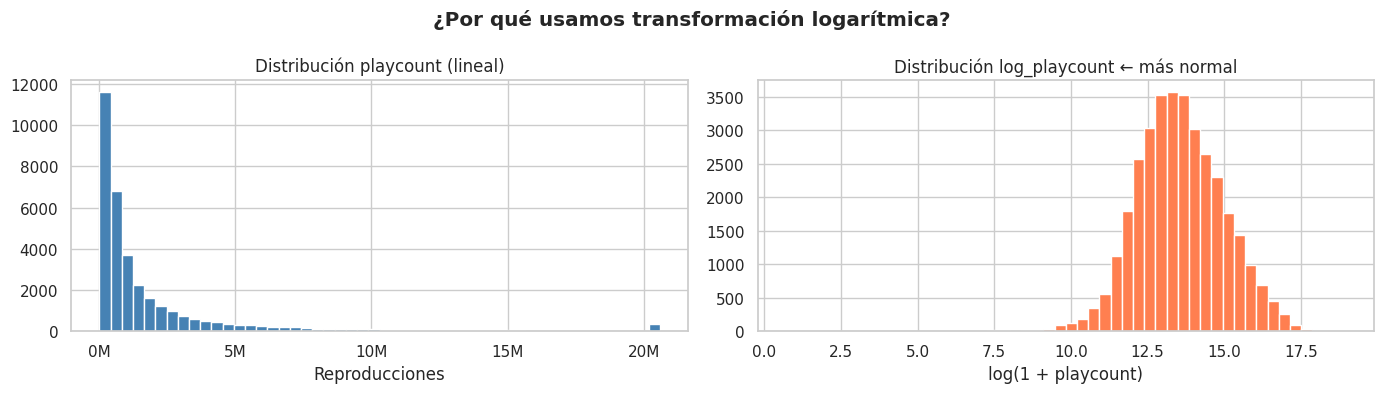

Skewness playcount:     8.09
Skewness log_playcount: -0.39


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

p99 = df_clean['playcount'].quantile(0.99)

axes[0].hist(df_clean['playcount'].clip(upper=p99), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución playcount (lineal)')
axes[0].set_xlabel('Reproducciones')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

axes[1].hist(df_clean['log_playcount'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribución log_playcount ← más normal')
axes[1].set_xlabel('log(1 + playcount)')

plt.suptitle('¿Por qué usamos transformación logarítmica?', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness playcount:     {df_clean["playcount"].skew():.2f}')
print(f'Skewness log_playcount: {df_clean["log_playcount"].skew():.2f}')

### Distribución de duration_min con boxplot

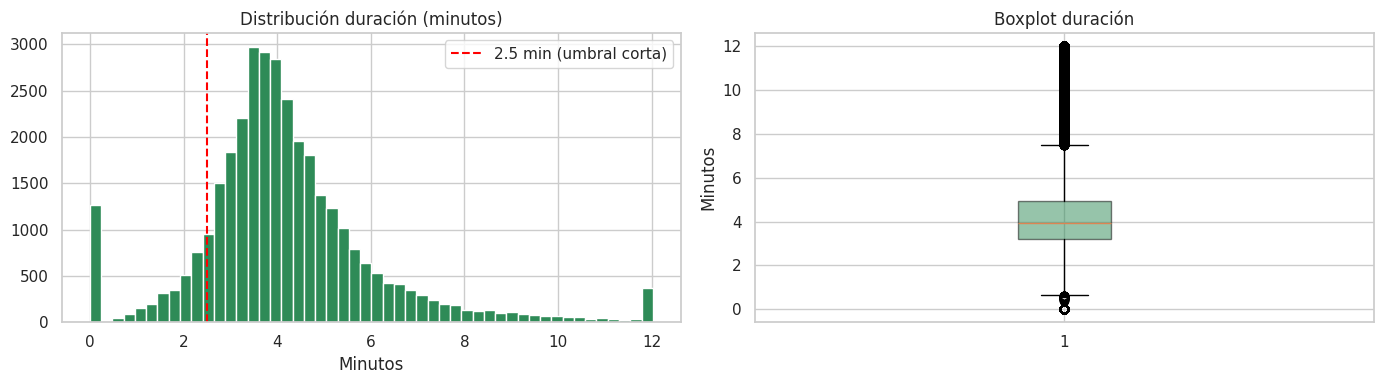

Media duración: 4.23 min
Canciones cortas (<2.5 min): 4,005 (11.7%)


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dur_ok   = df_clean['duration_min'].dropna()
dur_clip = dur_ok.clip(upper=dur_ok.quantile(0.99))

axes[0].hist(dur_clip, bins=50, color='seagreen', edgecolor='white')
axes[0].set_title('Distribución duración (minutos)')
axes[0].set_xlabel('Minutos')
axes[0].axvline(2.5, color='red', linestyle='--', label='2.5 min (umbral corta)')
axes[0].legend()

axes[1].boxplot(dur_clip, vert=True, patch_artist=True,
                boxprops=dict(facecolor='seagreen', alpha=0.5))
axes[1].set_title('Boxplot duración')
axes[1].set_ylabel('Minutos')

plt.tight_layout()
plt.show()

print(f'Media duración: {dur_ok.mean():.2f} min')
print(f'Canciones cortas (<2.5 min): {(dur_ok < 2.5).sum():,} ({(dur_ok < 2.5).mean()*100:.1f}%)')

### Top 15 artistas (código original mantenido, ahora con df_clean correcto)

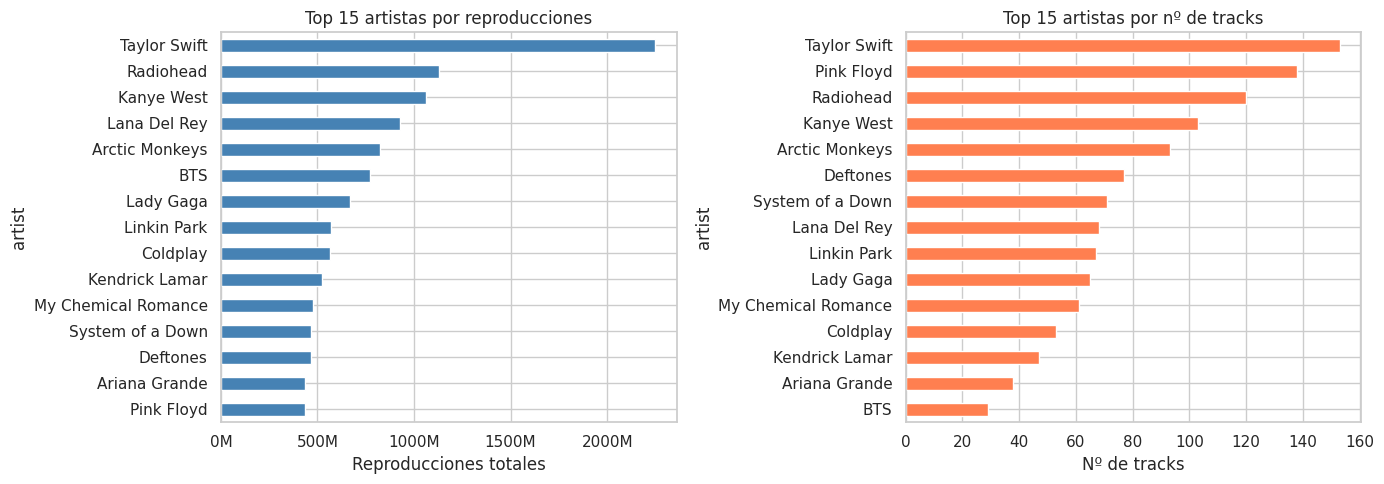

Top 5 artistas concentran 8.7% de reproducciones


In [82]:
top_artists = (
    df_clean
    .groupby('artist')[['playcount', 'name']]
    .agg({'playcount': 'sum', 'name': 'count'})
    .rename(columns={'playcount': 'total_plays', 'name': 'n_tracks'})
    .sort_values('total_plays', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_artists.sort_values('total_plays').plot.barh(
    y='total_plays', ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Top 15 artistas por reproducciones')
axes[0].set_xlabel('Reproducciones totales')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

top_artists.sort_values('n_tracks').plot.barh(
    y='n_tracks', ax=axes[1], color='coral', legend=False
)
axes[1].set_title('Top 15 artistas por nº de tracks')
axes[1].set_xlabel('Nº de tracks')

plt.tight_layout()
plt.show()

top5_share = top_artists['total_plays'].head(5).sum() / df_clean['playcount'].sum() * 100
print(f'Top 5 artistas concentran {top5_share:.1f}% de reproducciones')

### Análisis por tag (género) — solo tracks con tag asignado --> No funciona

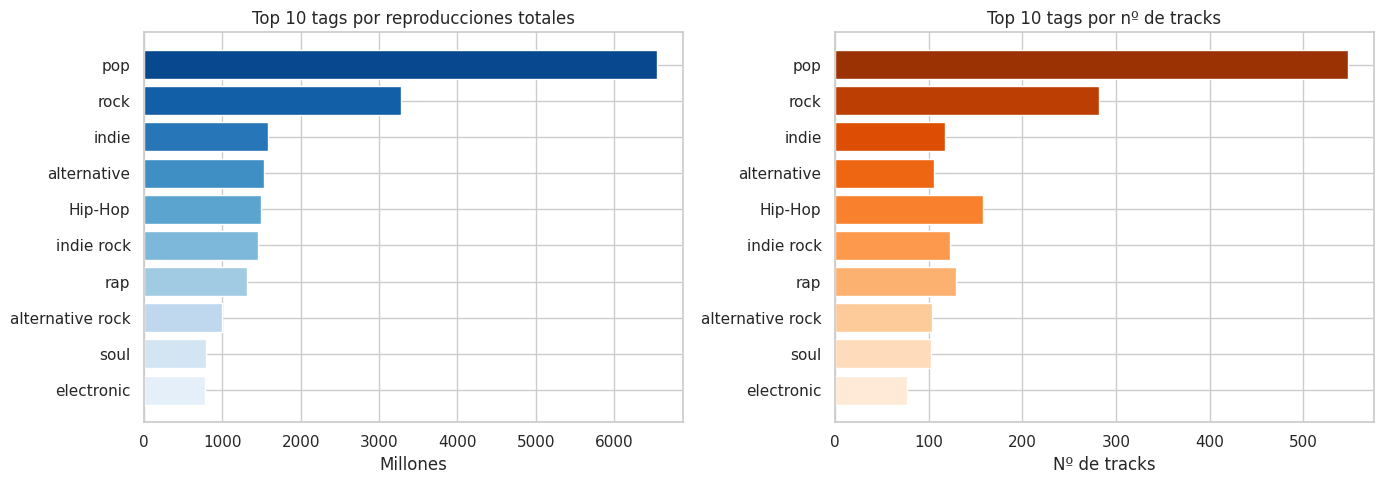

In [83]:
df_con_tag = df_clean.dropna(subset=['tag']).copy()

if len(df_con_tag) > 0:
    stats_tag = (
        df_con_tag
        .groupby('tag')
        .agg(
            n_tracks        =('name', 'count'),
            plays_medio     =('playcount', 'mean'),
            plays_total     =('playcount', 'sum'),
            engagement_medio=('playcount_per_listener', 'mean'),
        )
        .reset_index()
    )
    top10_tag = stats_tag.sort_values('plays_total', ascending=False).head(10)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(top10_tag['tag'], top10_tag['plays_total'] / 1e6,
                 color=sns.color_palette('Blues_r', 10))
    axes[0].invert_yaxis()
    axes[0].set_title('Top 10 tags por reproducciones totales')
    axes[0].set_xlabel('Millones')

    axes[1].barh(top10_tag['tag'], top10_tag['n_tracks'],
                 color=sns.color_palette('Oranges_r', 10))
    axes[1].invert_yaxis()
    axes[1].set_title('Top 10 tags por nº de tracks')
    axes[1].set_xlabel('Nº de tracks')

    plt.tight_layout()
    plt.show()
else:
    print('⚠️  No hay tracks con tag para analizar.')

### Análisis geográfico — excluimos GLOBAL y UNKNOWN para este análisis

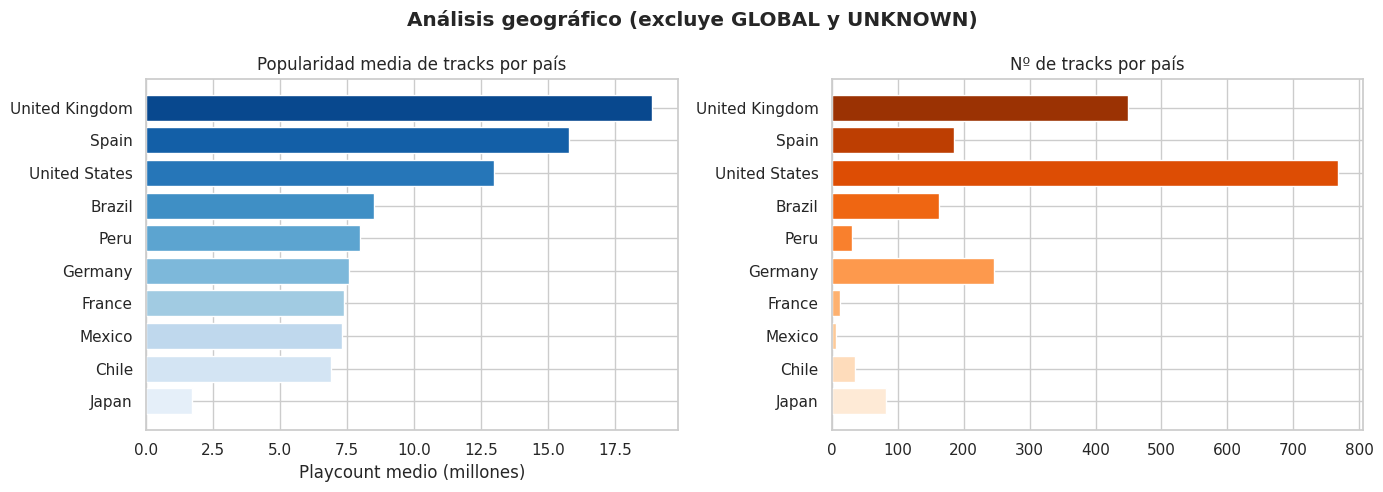

In [84]:
df_geo = df_clean[~df_clean['country'].isin(['UNKNOWN', 'GLOBAL'])].dropna(subset=['country'])

if len(df_geo) > 0:
    stats_pais = (
        df_geo
        .groupby('country')
        .agg(
            n_tracks       =('name', 'count'),
            plays_medio    =('playcount', 'mean'),
            engagement_medio=('playcount_per_listener', 'mean'),
        )
        .sort_values('plays_medio', ascending=False)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(stats_pais['country'], stats_pais['plays_medio'] / 1e6,
                 color=sns.color_palette('Blues_r', len(stats_pais)))
    axes[0].invert_yaxis()
    axes[0].set_title('Popularidad media de tracks por país')
    axes[0].set_xlabel('Playcount medio (millones)')

    axes[1].barh(stats_pais['country'], stats_pais['n_tracks'],
                 color=sns.color_palette('Oranges_r', len(stats_pais)))
    axes[1].invert_yaxis()
    axes[1].set_title('Nº de tracks por país')

    plt.suptitle('Análisis geográfico (excluye GLOBAL y UNKNOWN)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  Pocos tracks con país asignado en df_merged. El análisis geográfico es limitado.')
    print('   Para enriquecer: aumentar las páginas en geo.getTopTracks en el pipeline.')

### Distribución de playcount por is_hit e is_short_track

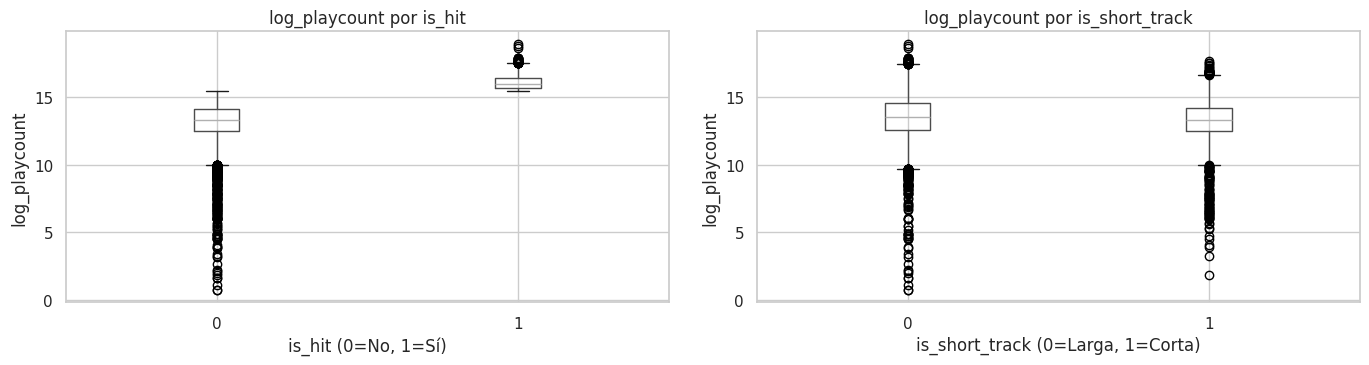

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean.boxplot(column='log_playcount', by='is_hit', ax=axes[0])
axes[0].set_xlabel('is_hit (0=No, 1=Sí)')
axes[0].set_ylabel('log_playcount')
plt.sca(axes[0])
plt.title('log_playcount por is_hit')

df_clean.boxplot(column='log_playcount', by='is_short_track', ax=axes[1])
axes[1].set_xlabel('is_short_track (0=Larga, 1=Corta)')
axes[1].set_ylabel('log_playcount')
plt.sca(axes[1])
plt.title('log_playcount por is_short_track')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 9. Correlaciones

### Spearman entre duration_min y playcount (código original mantenido)

In [86]:
idx = df_clean[['duration_min', 'playcount']].dropna().index
rho, p = spearmanr(df_clean.loc[idx, 'duration_min'], df_clean.loc[idx, 'playcount'])

print(f'Spearman duration_min vs playcount: ρ={rho:.3f}, p={p:.4f}')
print(f'Interpretación: {"significativo" if p < 0.05 else "no significativo"} (α=0.05)')

Spearman duration_min vs playcount: ρ=-0.089, p=0.0000
Interpretación: significativo (α=0.05)


### Heatmap de correlaciones de Spearman

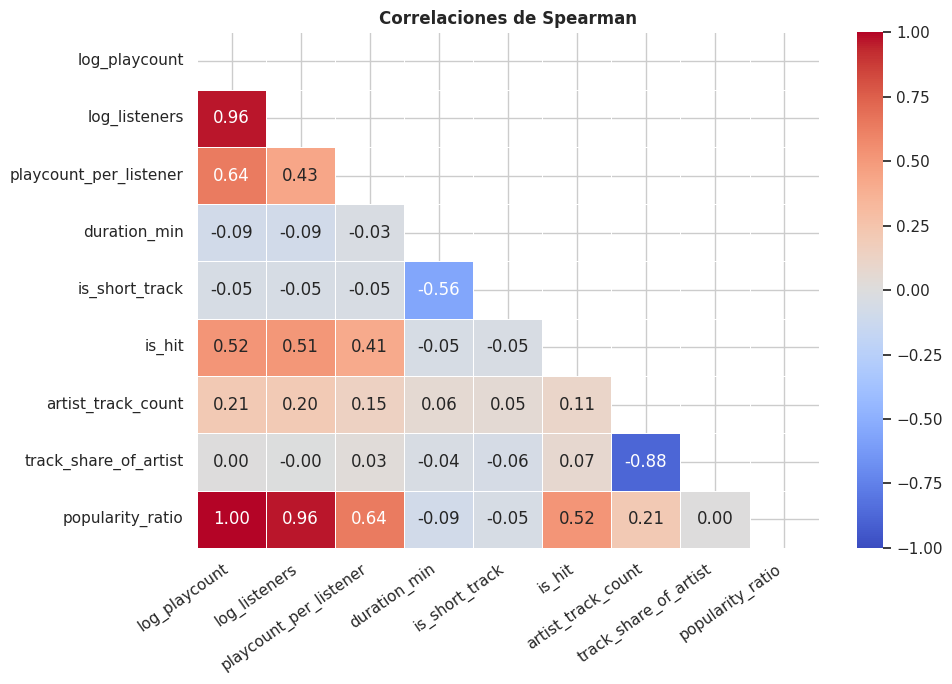

Variables más correlacionadas con log_playcount:
  + popularity_ratio: ρ=1.000
  + log_listeners: ρ=0.965
  + playcount_per_listener: ρ=0.637
  + is_hit: ρ=0.520


In [87]:
cols_posibles = [
    'log_playcount', 'log_listeners', 'playcount_per_listener',
    'duration_min', 'is_short_track', 'is_hit',
    'artist_track_count', 'track_share_of_artist', 'popularity_ratio'
]
cols_numericas = [c for c in cols_posibles if c in df_clean.columns]

corr = df_clean[cols_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlaciones de Spearman', fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

if 'log_playcount' in corr.columns:
    corr_target = corr['log_playcount'].drop('log_playcount').abs().sort_values(ascending=False)
    print('Variables más correlacionadas con log_playcount:')
    for feat, r in corr_target.head(4).items():
        signo = '+' if corr.loc['log_playcount', feat] > 0 else '-'
        print(f'  {signo} {feat}: ρ={r:.3f}')

---
## 10. Tests estadísticos

### 1. Mann-Whitney U: canciones cortas vs largas (código original completado)


* H0: la distribución de playcount es igual entre tracks cortos y largos

In [88]:
short = df_clean[df_clean['is_short_track'] == 1]['playcount'].dropna()
long  = df_clean[df_clean['is_short_track'] == 0]['playcount'].dropna()

stat_mw, p_mw = mannwhitneyu(short, long, alternative='two-sided')

print('=== Mann-Whitney U: cortas vs largas ===')
print(f'  U: {stat_mw:.2f} | p-valor: {p_mw:.6f}')
print(f'  → {"se rechaza H0" if p_mw < 0.05 else "no se rechaza H0"} (α=0.05)')
if p_mw < 0.05:
    mas_popular = 'cortas' if short.median() > long.median() else 'largas'
    print(f'  → Las canciones {mas_popular} tienen mayor playcount mediano.')
    print(f'     Mediana cortas: {short.median():,.0f} | Mediana largas: {long.median():,.0f}')

=== Mann-Whitney U: cortas vs largas ===
  U: 54880942.00 | p-valor: 0.000000
  → se rechaza H0 (α=0.05)
  → Las canciones largas tienen mayor playcount mediano.
     Mediana cortas: 595,006 | Mediana largas: 751,270


### 2. Kruskal-Wallis: diferencias por género (tag) --> No funciona

* H0: la distribución de playcount es igual en todos los géneros

In [89]:
df_con_tag_kw = df_clean.dropna(subset=['tag', 'playcount'])

# Solo tags con al menos 5 tracks (grupos muy pequeños no son estadísticamente fiables)
tags_validos = df_con_tag_kw['tag'].value_counts()
tags_validos = tags_validos[tags_validos >= 5].index.tolist()

grupos = [
    df_con_tag_kw[df_con_tag_kw['tag'] == tag]['playcount'].values
    for tag in tags_validos
]

if len(grupos) >= 2:
    stat_kw, p_kw = kruskal(*grupos)
    print('=== Kruskal-Wallis: diferencias por tag/género ===')
    print(f'  Géneros con ≥5 tracks: {len(grupos)}')
    print(f'  H: {stat_kw:.2f} | p-valor: {p_kw:.6f}')
    print(f'  → {"se rechaza H0" if p_kw < 0.05 else "no se rechaza H0"} (α=0.05)')
    if p_kw < 0.05:
        print('  → Hay diferencias significativas de popularidad entre géneros.')
else:
    print('⚠️  Insuficientes grupos para Kruskal-Wallis.')

=== Kruskal-Wallis: diferencias por tag/género ===
  Géneros con ≥5 tracks: 85
  H: 384.48 | p-valor: 0.000000
  → se rechaza H0 (α=0.05)
  → Hay diferencias significativas de popularidad entre géneros.


### 3. Análisis visual de duración por rangos (código original completado) 

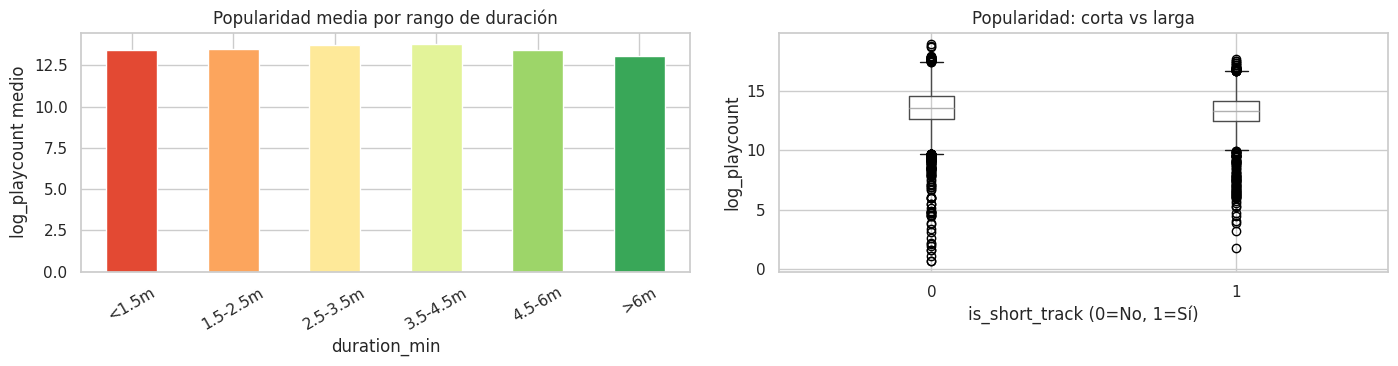

In [90]:
rangos = pd.cut(
    df_clean['duration_min'],
    bins=[0, 1.5, 2.5, 3.5, 4.5, 6, 100],
    labels=['<1.5m', '1.5-2.5m', '2.5-3.5m', '3.5-4.5m', '4.5-6m', '>6m']
)
pop_por_rango = df_clean.groupby(rangos, observed=True)['log_playcount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pop_por_rango.plot.bar(ax=axes[0], color=sns.color_palette('RdYlGn', 6))
axes[0].set_title('Popularidad media por rango de duración')
axes[0].set_ylabel('log_playcount medio')
axes[0].tick_params(axis='x', rotation=30)

df_clean.boxplot(column='log_playcount', by='is_short_track', ax=axes[1])
axes[1].set_xlabel('is_short_track (0=No, 1=Sí)')
axes[1].set_ylabel('log_playcount')
plt.sca(axes[1])
plt.title('Popularidad: corta vs larga')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 11. Modelado



### 1. Regresión OLS explicativa sobre `log_playcount`

* Variables explicativas: duration_min y playcount_per_listener

In [91]:
import statsmodels.api as sm
df_model = df_clean[['log_playcount', 'duration_min', 'playcount_per_listener']].dropna()

X_ols = df_model[['duration_min', 'playcount_per_listener']]
X_ols = sm.add_constant(X_ols)
y_ols = df_model['log_playcount']

model_ols = sm.OLS(y_ols, X_ols).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          log_playcount   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     4991.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:34:14   Log-Likelihood:                -57349.
No. Observations:               34369   AIC:                         1.147e+05
Df Residuals:                   34366   BIC:                         1.147e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     12

### 2. Random Forest — Clasificación y Regresión

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, r2_score, mean_absolute_error
from xgboost import XGBClassifier

### Preparar features para ML

#### FEATURES: columnas que usamos para predecir

In [93]:
FEATURES = [
    'log_listeners',
    'duration_min',
    'is_short_track',
    'tag_encoded',
    'artist_track_count',
    'track_share_of_artist',
    'playcount_per_listener',
    'log_playcount', 'is_hit']


In [94]:
FEATURES = [f for f in FEATURES if f in df_clean.columns]


In [95]:
X = df_clean[FEATURES]
y = df_clean['is_hit']

* y para clasificación: is_hit (0 o 1)
* y para regresión:     log_playcount (continuo)

#### Train / Test split — stratify para conservar proporción de hits

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 27,495 | Test: 6,874


### Clasificación: ¿es un hit? (is_hit)

In [97]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_clf.fit(X_train, y_train)
y_pred_clf = rf_clf.predict(X_test)


from sklearn.metrics import classification_report
print('=== Clasificación (is_hit) ===')
print(classification_report(y_test, y_pred_clf, target_names=['No hit', 'Hit']))

=== Clasificación (is_hit) ===
              precision    recall  f1-score   support

      No hit       1.00      1.00      1.00      6176
         Hit       1.00      1.00      1.00       698

    accuracy                           1.00      6874
   macro avg       1.00      1.00      1.00      6874
weighted avg       1.00      1.00      1.00      6874



### Regresión: predecir log_playcount

* Variable objetivo:

In [98]:
df_clean['log_playcount'] = np.log1p(df_clean['playcount'])

In [99]:
X = df_clean[FEATURES]
y_reg = df_clean['log_playcount']

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [101]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

In [102]:
rf_reg.fit(X_train, y_train_reg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [103]:
y_pred_reg = rf_reg.predict(X_test)

In [104]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("=== Regresión (log_playcount) ===")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

=== Regresión (log_playcount) ===
RMSE: 0.006
R2: 1.000


### *Conclusión para Streamlit*

| Modelo | Tipo          | Uso          |
| ------ | ------------- | ------------ |
| rf_clf | clasificación | Streamlit  |
| rf_reg | regresión     | Análisis   |


### *Feature importance*

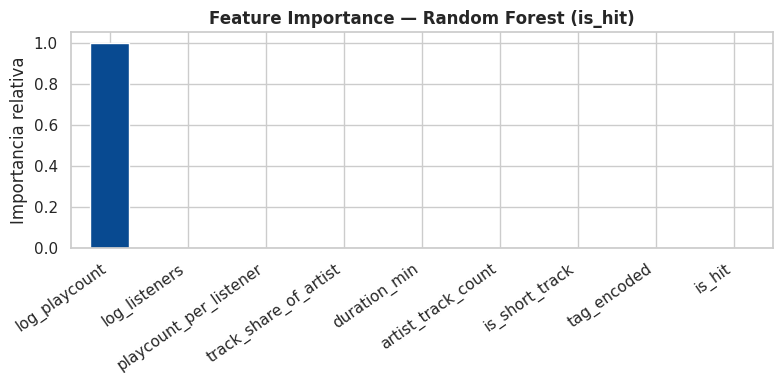

Las 3 variables más importantes:
  → log_playcount: 100.0%
  → log_listeners: 0.0%
  → playcount_per_listener: 0.0%


In [105]:
importancias = pd.Series(
    rf_reg.feature_importances_,
    index=X_train.columns  
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot.bar(ax=ax, color=sns.color_palette('Blues_r', len(importancias)))
ax.set_title('Feature Importance — Random Forest (is_hit)', fontweight='bold')
ax.set_ylabel('Importancia relativa')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('Las 3 variables más importantes:')
for feat, val in importancias.head(3).items():
    print(f'  → {feat}: {val*100:.1f}%')

### Función de predicción final 

In [106]:
X = df_clean[FEATURES]

In [107]:
def predecir_hit(nombre, artista, duracion_min, genero, oyentes_estimados):
    """Predice la probabilidad de que una canción sea un hit."""
    
    genero_enc = le_tag.transform([genero])[0] if genero in le_tag.classes_ else 0

    # ✅ 1. CREAR datos primero
    datos = pd.DataFrame([{
        'log_listeners'          : np.log1p(oyentes_estimados),
        'duration_min'           : duracion_min,
        'is_short_track'         : int(duracion_min < 2.5),
        'tag_encoded'            : genero_enc,
        'artist_track_count'     : 1,
        'track_share_of_artist'  : 1.0,
        'playcount_per_listener' : 5.0,
    }])

    # ✅ 2. ORDENAR columnas según el modelo
    datos = datos.reindex(columns=FEATURES, fill_value=0)

    # predicción
    prob = rf_clf.predict_proba(datos)[0][1] * 100

    clasificacion = (
        '🚀 Hit potencial' if prob >= 70 
        else ('🟡 Potencial medio' if prob >= 45 else '📉 Bajo potencial')
    )

    print('=' * 50)
    print(f'  🎵 {nombre} — {artista}')
    print('=' * 50)
    print(f'  Probabilidad de hit: {prob:.1f}%')
    print(f'  Clasificación:       {clasificacion}')
    print(f'  Género:              {genero}')
    print(f'  Duración:            {duracion_min:.1f} min{" (corta ⏱️)" if duracion_min < 2.5 else ""}')
    print('=' * 50)

    return prob

---
## 12. Conclusiones

| Análisis | Qué evaluar |
|---|---|
| Distribución playcount | Muy sesgada → necesaria transformación log |
| Mann-Whitney | p < 0.05 → hay diferencia real de popularidad entre cortas y largas |
| Kruskal-Wallis | p < 0.05 → el género influye en la popularidad |
| Spearman | Signo de ρ → si negativo, canciones cortas son más populares |
| Random Forest (clf) | Ver F1 en clase 'Hit'. F1 > 0.7 es aceptable |
| Feature importance | `log_listeners` suele ser el predictor dominante |

### Limitaciones
- `df_merged` hereda las limitaciones de ambas fuentes: tags solo en ~10% de tracks, country con mucha presencia de GLOBAL/UNKNOWN.
- `published` en `backup_tracks` es la fecha de adición al catálogo de Last.fm, no la fecha de lanzamiento original.
- `lastfm_dataset` aporta country y genre_tag, pero la cobertura de mbid compartidos con backup_tracks es parcial.


# 💡 Ideas para Streamlit / App web



Con lo que tienes, puedes construir una app con estas secciones:



### Página 1 — Predictor de hit


```python
# En app.py:
import streamlit as st
import pickle


* Cargar modelo y encoders guardados

In [108]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(rf_clf, 'models/modelo_hit.pkl')
joblib.dump(le_tag, 'models/encoder_tag.pkl')
joblib.dump(FEATURES, 'models/features.pkl')


['models/features.pkl']

In [109]:
import joblib

rf_clf = joblib.load('models/modelo_hit.pkl')
le_tag = joblib.load('models/encoder_tag.pkl')

In [110]:
import os
print(os.listdir('models'))

['modelo_hit.pkl', 'encoder_tag.pkl', 'features.pkl']



### Página 2 — Dashboard del mercado


- Top 15 canciones (barplot)
- Géneros por popularidad (barplot)
- Mapa de calor géneros × países



### Página 3 — Explorador de artistas


- Input: nombre del artista
- Output: sus tracks en el dataset, popularidad media, géneros



### Ideas de ML adicionales con las variables actuales



| Idea | Variables necesarias | Factibilidad |
|---|---|---|
| Predecir si un track será hit | listeners, genre, country, duration | ✅ Ya tienes esto |
| Clustering de géneros musicales | playcount, engagement, pct_cortas | ✅ KMeans con tus datos |
| Ranking de países con más potencial | plays_medio por país | ✅ Con geo.getTopTracks |
| Detectar artistas emergentes | n_tracks_artista, plays_medio, tendencia | ✅ Con datos temporales |
| Predecir viralidad por duración | is_short_track + playcount | ✅ Ya tienes esto |
| Audio features (danceability, BPM...) | — | ❌ Necesitas Spotify API |
